In [1]:
from pathlib import Path
from typing import Callable

import numpy as np
from numpy.typing import NDArray
from astropy.io import fits
from astropy.table import Table, vstack

from bloodmoon.mask import CodedMaskCamera, codedmask
import darksun as ds
from darksun.data import DataLoader

In [2]:
DATASET: str =  'detected'

In [ ]:
def grep_phIDs(sdl: DataLoader, cond: Callable[[NDArray], NDArray]) -> NDArray:
    """Extracts photon IDs from given list based on mask output X coord condition."""
    mask = cond(sdl.DLdata['X'])
    return sdl.DLdata['ID'][mask]


def intersect_IDs(all_ids: NDArray, collected_ids: NDArray, uniqueIDs: bool = True) -> NDArray:
    """Extracts valid photon ID indexes within collected photons list."""
    _, _, idx_b = np.intersect1d(all_ids, collected_ids, assume_unique=uniqueIDs, return_indices=True)
    return idx_b


def merge_photons(
    phs_left: fits.FITS_rec,
    phs_right: fits.FITS_rec,
    save_to: str | Path | None = None,
    tab_name: str | None = None,
    header: fits.Header | None = None,
) -> fits.FITS_rec:
    """Merges given data."""
    tl, tr = map(lambda x: Table(x), (phs_left, phs_right))
    merged_table = vstack([tl, tr])
    merged_hdu = fits.BinTableHDU(data=merged_table, name=tab_name)
    print(f'Merged photon lists with total elements: {len(merged_table)}')

    if save_to is not None:
        print("# Saving merged photon list...")
        if header is not None:
            try:
                merged_hdu.header.extend(header, strip=True, update=True)
                print('Updated BinTable header!')
            except Exception as e:
                print(f'Encountered error {e}, skipping header update...')
        hdu_list = fits.HDUList([fits.PrimaryHDU(), merged_hdu])
        hdu_list.writeto(save_to, output_verify="fix+ignore")
        hdu_list.close()
        print("# Saving completed!")
    
    return merged_hdu.data

In [4]:
dirpath: str = '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'

wfm: CodedMaskCamera = codedmask(f'{dirpath}/mask_NTHT_20260129_CORRECTED.fits')

In [5]:
to_files: str = 'CameraGeometry/mask_warps/pYwarp_2arcmin/m2arcmin/cam1a'

sdl_mask: DataLoader = ds.get_data(f'{dirpath}/{to_files}/pYwarp_m2arcmin_2-50keV_1ks_cam1a_mask.fits')
sdl: DataLoader = ds.get_data(f'{dirpath}/{to_files}/pYwarp_m2arcmin_2-50keV_1ks_cam1a_detected.fits')

CATALOG ='camera_benchmark_catalogue.fits' / Catalog file                        [astropy.io.fits.card]


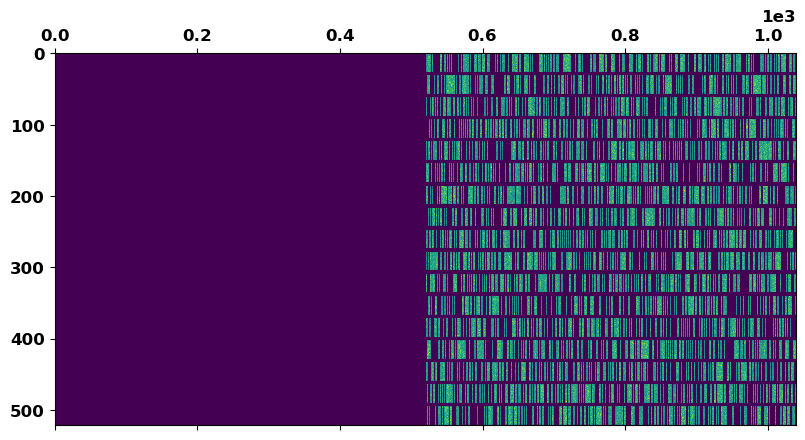

In [6]:
import matplotlib.pyplot as plt

bins = wfm.bins_mask
cond = (sdl_mask.DLdata['X'] >= 0.0)

hist, *_ = np.histogram2d(sdl_mask.DLdata['Y'][cond], sdl_mask.DLdata['X'][cond], bins=[bins.y, bins.x])

plt.matshow(hist)

In [7]:
right_phs = grep_phIDs(sdl_mask, lambda x: x >= 0.0)
idxs = intersect_IDs(right_phs, sdl.DLdata['ID'])

In [8]:
len(idxs), len(sdl.DLdata['ID']), len(right_phs)

(688993, 1379270, 6194721)

In [9]:
len(sdl.DLdata[idxs])

688993

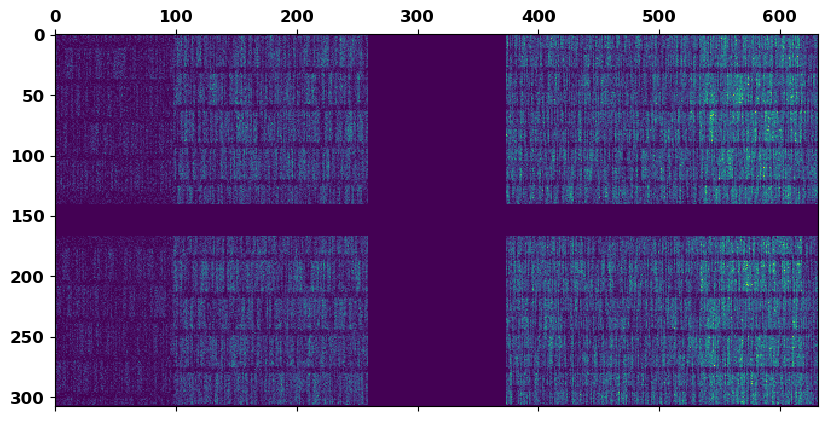

In [10]:
from bloodmoon.mask import count

det = count(wfm, sdl.DLdata[idxs])[0]

plt.matshow(det)

Merged photon lists with total elements: 1377986
# Saving merged photon list...
Updated BinTable header!
# Saving completed!


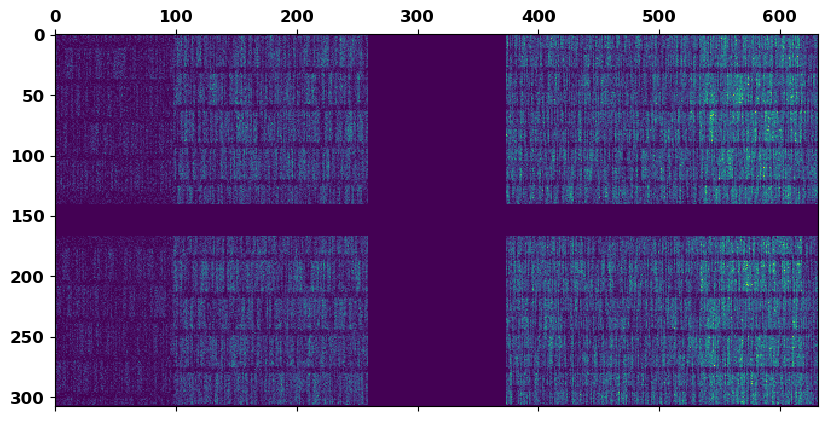

In [12]:
merged = merge_photons(sdl.DLdata[idxs], sdl.DLdata[idxs], save_to='/home/edoardo/Desktop/test.fits', header=sdl.header)

det = count(wfm, merged)[0]

plt.matshow(det)

In [ ]:
len(merged) / len(sdl.DLdata[idxs])

2.0